In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Day16_Student_Wellbeing_Survey.csv to Day16_Student_Wellbeing_Survey.csv


In [3]:
df = pd.read_csv("Day16_Student_Wellbeing_Survey.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 600
Number of columns: 20


In [4]:
df.head()

,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
0,STU0001,21,Data Science,3,Bengaluru,Hostel,No,Yes,Good,Café,15.2,5.7,3.2,3,11.8,5.4,63.1,3.2,5131.0,7.8
1,STU0002,21,Data Science,4,Pune,Hostel,Yes,No,Poor,Library,17.6,7.7,3.5,4,20.3,2.1,74.2,3.8,3508.0,9.2
2,STU0003,22,Life Sciences,2,Chandigarh,Home,Yes,No,Poor,Home,18.9,6.4,2.8,1,15.0,5.2,77.3,4.0,4584.0,7.7
3,STU0004,18,Business,4,Bengaluru,Hostel,Yes,Yes,Average,Café,19.5,6.7,3.0,5,12.1,4.7,67.0,4.0,5456.0,5.3
4,STU0005,20,Business,3,Jammu,Shared Apartment,Yes,No,Good,Home,18.4,7.3,3.0,1,30.2,5.4,65.6,3.2,11732.0,15.9


In [5]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Column Names:
['Student_ID', 'Age', 'Faculty', 'Year_of_Study', 'City', 'Accommodation', 'Scholarship', 'Part_Time_Job', 'Internet_Quality', 'Preferred_Study_Space', 'Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours', 'Exercise_Days_Per_Week', 'Commute_Time_Minutes', 'Stress_Score', 'Academic_Readiness_Score', 'Overall_Satisfaction', 'Monthly_Discretionary_Spending', 'Social_Activity_Hours_Per_Week']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    object 
 1   Age                             600 non-null    int64  
 2   Faculty                         600 non-null    object 
 3   Year_of_Study                   600 non-null    int64  
 4   City                            600 non-null    object 
 5   Accommodation    

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Student_ID                        0
Age                               0
Faculty                           0
Year_of_Study                     0
City                              0
Accommodation                     0
Scholarship                       0
Part_Time_Job                     0
Internet_Quality                  0
Preferred_Study_Space             0
Weekly_Study_Hours                0
Average_Sleep_Hours               0
Daily_Screen_Time_Hours           0
Exercise_Days_Per_Week            0
Commute_Time_Minutes              0
Stress_Score                      0
Academic_Readiness_Score          0
Overall_Satisfaction              0
Monthly_Discretionary_Spending    0
Social_Activity_Hours_Per_Week    0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
variables = [
    "Weekly_Study_Hours",
    "Average_Sleep_Hours",
    "Daily_Screen_Time_Hours",
    "Stress_Score",
    "Academic_Readiness_Score"
]

selected_df = df[variables]

selected_df.head()

,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Stress_Score,Academic_Readiness_Score
0,15.2,5.7,3.2,5.4,63.1
1,17.6,7.7,3.5,2.1,74.2
2,18.9,6.4,2.8,5.2,77.3
3,19.5,6.7,3.0,4.7,67.0
4,18.4,7.3,3.0,5.4,65.6


In [9]:
mean_values = df[variables].mean()

print("Mean:")
print(mean_values)

Mean:
Weekly_Study_Hours          15.691000
Average_Sleep_Hours          6.997500
Daily_Screen_Time_Hours      4.503000
Stress_Score                 4.464500
Academic_Readiness_Score    71.773167
dtype: float64


In [10]:
median_values = df[variables].median()

print("Median:")
print(median_values)

Median:
Weekly_Study_Hours          15.40
Average_Sleep_Hours          7.00
Daily_Screen_Time_Hours      4.20
Stress_Score                 4.50
Academic_Readiness_Score    71.65
dtype: float64


In [11]:
for column in variables:
    print("\n", column)
    print(df[column].mode().tolist())


 Weekly_Study_Hours
[13.1, 14.6, 15.3, 17.1]

 Average_Sleep_Hours
[7.0]

 Daily_Screen_Time_Hours
[3.5]

 Stress_Score
[4.7, 4.9]

 Academic_Readiness_Score
[71.1, 71.4, 78.0]


In [12]:
results = []

for column in variables:
    minimum = df[column].min()
    maximum = df[column].max()
    range_value = maximum - minimum
    variance = df[column].var()
    std_dev = df[column].std()
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    results.append([
        column,
        range_value,
        variance,
        std_dev,
        q1,
        q3,
        iqr
    ])

stats_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Range",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR"
    ]
)

stats_df

,Variable,Range,Variance,Standard Deviation,Q1,Q3,IQR
0,Weekly_Study_Hours,30.0,19.217047,4.383725,13.000,18.425,5.425
1,Average_Sleep_Hours,5.0,0.703383,0.838679,6.475,7.600,1.125
2,Daily_Screen_Time_Hours,11.2,3.469006,1.862527,3.200,5.400,2.200
3,Stress_Score,8.4,2.782494,1.668081,3.300,5.700,2.400
4,Academic_Readiness_Score,56.1,93.981967,9.694430,65.200,78.025,12.825


In [13]:
greatest_variability = stats_df.loc[
    stats_df["Standard Deviation"].idxmax()
]

print("Variable with greatest variability:")
print(greatest_variability)

Variable with greatest variability:
Variable              Academic_Readiness_Score
Range                                     56.1
Variance                             93.981967
Standard Deviation                     9.69443
Q1                                        65.2
Q3                                      78.025
IQR                                     12.825
Name: 4, dtype: object


In [14]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\nVariable:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", len(outliers))

    return outliers

In [15]:
weekly_outliers = detect_outliers("Weekly_Study_Hours")
weekly_outliers[["Student_ID", "Weekly_Study_Hours"]]


Variable: Weekly_Study_Hours
Q1: 13.0
Q3: 18.424999999999997
IQR: 5.424999999999997
Lower Bound: 4.862500000000004
Upper Bound: 26.562499999999993
Number of outliers: 8


,Student_ID,Weekly_Study_Hours
130,STU0131,27.8
159,STU0160,26.6
276,STU0277,26.6
381,STU0382,4.0
460,STU0461,27.2
512,STU0513,34.0
542,STU0543,4.3
572,STU0573,27.2


In [16]:
screen_outliers = detect_outliers("Daily_Screen_Time_Hours")
screen_outliers[["Student_ID", "Daily_Screen_Time_Hours"]]


Variable: Daily_Screen_Time_Hours
Q1: 3.2
Q3: 5.4
IQR: 2.2
Lower Bound: -0.10000000000000009
Upper Bound: 8.700000000000001
Number of outliers: 18


,Student_ID,Daily_Screen_Time_Hours
17,STU0018,9.8
85,STU0086,10.1
141,STU0142,11.8
172,STU0173,10.4
266,STU0267,12.4
303,STU0304,12.0
304,STU0305,10.6
332,STU0333,11.3
377,STU0378,9.1
390,STU0391,12.0


In [17]:
commute_outliers = detect_outliers("Commute_Time_Minutes")
commute_outliers[["Student_ID", "Commute_Time_Minutes"]]


Variable: Commute_Time_Minutes
Q1: 13.375
Q3: 31.525
IQR: 18.15
Lower Bound: -13.849999999999998
Upper Bound: 58.75
Number of outliers: 4


,Student_ID,Commute_Time_Minutes
18,STU0019,65.2
216,STU0217,62.3
374,STU0375,72.5
397,STU0398,118.0


In [18]:
spending_outliers = detect_outliers(
    "Monthly_Discretionary_Spending"
)

spending_outliers[
    ["Student_ID", "Monthly_Discretionary_Spending"]
]


Variable: Monthly_Discretionary_Spending
Q1: 4113.0
Q3: 7808.5
IQR: 3695.5
Lower Bound: -1430.25
Upper Bound: 13351.75
Number of outliers: 20


,Student_ID,Monthly_Discretionary_Spending
17,STU0018,28000.0
18,STU0019,16791.0
51,STU0052,13945.0
58,STU0059,14064.0
83,STU0084,31500.0
93,STU0094,19559.0
157,STU0158,14667.0
207,STU0208,14859.0
232,STU0233,13875.0
320,STU0321,14594.0


In [19]:
column = "Weekly_Study_Hours"

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df = df[
    (df[column] >= lower_bound) &
    (df[column] <= upper_bound)
]

print("Before removing outliers:")
print("Mean:", df[column].mean())
print("Median:", df[column].median())

print("\nAfter removing outliers:")
print("Mean:", clean_df[column].mean())
print("Median:", clean_df[column].median())

Before removing outliers:
Mean: 15.690999999999997
Median: 15.4

After removing outliers:
Mean: 15.60287162162162
Median: 15.350000000000001


In [20]:
A = df["Part_Time_Job"] == "Yes"
B = df["Stress_Score"] >= 7
C = df["Scholarship"] == "Yes"
D = df["Exercise_Days_Per_Week"] >= 3

print("Students with Part-Time Job:", A.sum())
print("Students with Stress Score >= 7:", B.sum())
print("Students with Scholarship:", C.sum())
print("Students exercising >= 3 days:", D.sum())

Students with Part-Time Job: 152
Students with Stress Score >= 7: 45
Students with Scholarship: 184
Students exercising >= 3 days: 356


In [21]:
P_A = A.mean()

print("P(A) =", P_A)

P(A) = 0.25333333333333335


In [22]:
P_B = B.mean()

print("P(B) =", P_B)

P(B) = 0.075


In [23]:
P_C = C.mean()

print("P(C) =", P_C)

P(C) = 0.30666666666666664


In [24]:
P_D = D.mean()

print("P(D) =", P_D)

P(D) = 0.5933333333333334


In [25]:
P_A_or_B = (A | B).mean()

print("P(A or B) =", P_A_or_B)

print(
    "Using formula:",
    P_A + P_B - (A & B).mean()
)

P(A or B) = 0.27666666666666667
Using formula: 0.2766666666666667


In [26]:
P_A_and_B = (A & B).mean()

print("Number of students in A and B:", (A & B).sum())
print("P(A and B) =", P_A_and_B)

Number of students in A and B: 31
P(A and B) = 0.051666666666666666


In [27]:
P_A_given_B = (A & B).sum() / B.sum()

print("P(A | B) =", P_A_given_B)

P(A | B) = 0.6888888888888889


In [28]:
P_B_given_A = (A & B).sum() / A.sum()

print("P(B | A) =", P_B_given_A)

P(B | A) = 0.20394736842105263


In [29]:
E1 = df["Year_of_Study"] == 1
E4 = df["Year_of_Study"] == 4

intersection = E1 & E4

print("Year 1 students:", E1.sum())
print("Year 4 students:", E4.sum())
print("Students in both Year 1 and Year 4:", intersection.sum())

Year 1 students: 164
Year 4 students: 120
Students in both Year 1 and Year 4: 0


In [30]:
P_A_times_P_B = P_A * P_B

print("P(A and B):", P_A_and_B)
print("P(A) × P(B):", P_A_times_P_B)

difference = abs(P_A_and_B - P_A_times_P_B)

print("Difference:", difference)

P(A and B): 0.051666666666666666
P(A) × P(B): 0.019
Difference: 0.03266666666666666


In [31]:
not_A = ~A

P_not_A = not_A.mean()

P_B_given_not_A = (B & not_A).sum() / not_A.sum()

print("P(not A):", P_not_A)
print("P(B | not A):", P_B_given_not_A)

P(not A): 0.7466666666666667
P(B | not A): 0.03125


In [32]:
bayes_result = (
    P_B_given_A * P_A
) / (
    P_B_given_A * P_A +
    P_B_given_not_A * P_not_A
)

print("P(A | B) using Bayes' theorem =", bayes_result)
print("P(A | B) direct calculation =", P_A_given_B)

P(A | B) using Bayes' theorem = 0.6888888888888889
P(A | B) direct calculation = 0.6888888888888889


In [33]:
academic = df["Academic_Readiness_Score"]

mean_academic = academic.mean()
std_academic = academic.std()

print("Mean:", mean_academic)
print("Standard Deviation:", std_academic)

Mean: 71.77316666666667
Standard Deviation: 9.694429667762527


In [34]:
highest_index = df["Academic_Readiness_Score"].idxmax()

highest_student = df.loc[
    highest_index,
    ["Student_ID", "Academic_Readiness_Score"]
]

print(highest_student)

Student_ID                  STU0131
Academic_Readiness_Score       98.0
Name: 130, dtype: object


In [35]:
highest_score = df.loc[
    highest_index,
    "Academic_Readiness_Score"
]

z_highest = (highest_score - mean_academic) / std_academic

print("Highest score:", highest_score)
print("Z-score:", z_highest)

Highest score: 98.0
Z-score: 2.705350828481123


In [36]:
lowest_index = df["Academic_Readiness_Score"].idxmin()

lowest_student = df.loc[
    lowest_index,
    ["Student_ID", "Academic_Readiness_Score"]
]

print(lowest_student)

Student_ID                  STU0543
Academic_Readiness_Score       41.9
Name: 542, dtype: object


In [37]:
lowest_score = df.loc[
    lowest_index,
    "Academic_Readiness_Score"
]

z_lowest = (lowest_score - mean_academic) / std_academic

print("Lowest score:", lowest_score)
print("Z-score:", z_lowest)

Lowest score: 41.9
Z-score: -3.081477476287823


In [38]:
print("Mean =", mean_academic)
print("Standard Deviation =", std_academic)

print("\nWithin 1 SD:")
print(mean_academic - std_academic,
      "to",
      mean_academic + std_academic)

print("\nWithin 2 SD:")
print(mean_academic - 2*std_academic,
      "to",
      mean_academic + 2*std_academic)

print("\nWithin 3 SD:")
print(mean_academic - 3*std_academic,
      "to",
      mean_academic + 3*std_academic)

Mean = 71.77316666666667
Standard Deviation = 9.694429667762527

Within 1 SD:
62.07873699890414 to 81.4675963344292

Within 2 SD:
52.38430733114161 to 91.16202600219172

Within 3 SD:
42.689877663379086 to 100.85645566995424


In [39]:
within_1 = (
    (academic >= mean_academic - std_academic) &
    (academic <= mean_academic + std_academic)
).mean() * 100

within_2 = (
    (academic >= mean_academic - 2*std_academic) &
    (academic <= mean_academic + 2*std_academic)
).mean() * 100

within_3 = (
    (academic >= mean_academic - 3*std_academic) &
    (academic <= mean_academic + 3*std_academic)
).mean() * 100

print("Actual percentage within 1 SD:", within_1, "%")
print("Actual percentage within 2 SD:", within_2, "%")
print("Actual percentage within 3 SD:", within_3, "%")

Actual percentage within 1 SD: 69.5 %
Actual percentage within 2 SD: 95.16666666666667 %
Actual percentage within 3 SD: 99.83333333333333 %


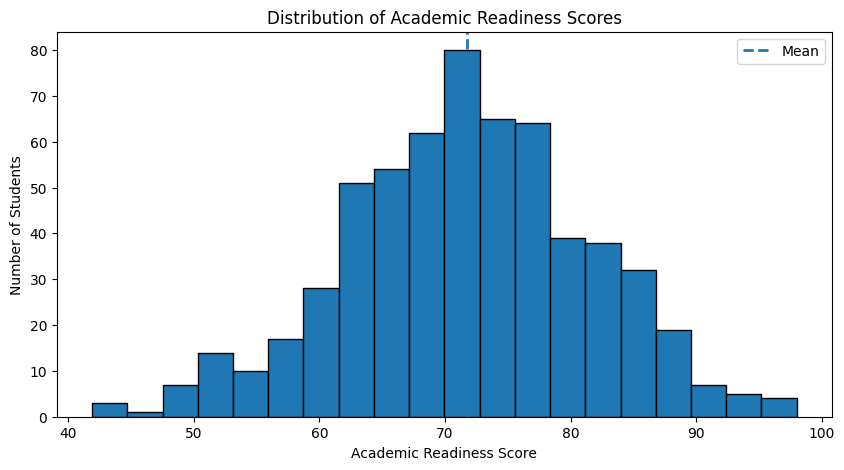

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    academic,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    mean_academic,
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.xlabel("Academic Readiness Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Academic Readiness Scores")
plt.legend()

plt.show()

In [41]:
summary = pd.DataFrame({
    "Measure": [
        "Mean",
        "Median",
        "Variance",
        "Standard Deviation",
        "Range",
        "Q1",
        "Q3",
        "IQR"
    ]
})

for column in variables:
    summary[column] = [
        df[column].mean(),
        df[column].median(),
        df[column].var(),
        df[column].std(),
        df[column].max() - df[column].min(),
        df[column].quantile(0.25),
        df[column].quantile(0.75),
        df[column].quantile(0.75) - df[column].quantile(0.25)
    ]

summary

,Measure,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Stress_Score,Academic_Readiness_Score
0,Mean,15.691000,6.997500,4.503000,4.464500,71.773167
1,Median,15.400000,7.000000,4.200000,4.500000,71.650000
2,Variance,19.217047,0.703383,3.469006,2.782494,93.981967
3,Standard Deviation,4.383725,0.838679,1.862527,1.668081,9.694430
4,Range,30.000000,5.000000,11.200000,8.400000,56.100000
5,Q1,13.000000,6.475000,3.200000,3.300000,65.200000
6,Q3,18.425000,7.600000,5.400000,5.700000,78.025000
7,IQR,5.425000,1.125000,2.200000,2.400000,12.825000


In [42]:
probability_summary = pd.DataFrame({
    "Event / Probability": [
        "P(A)",
        "P(B)",
        "P(C)",
        "P(D)",
        "P(A or B)",
        "P(A and B)",
        "P(A | B)",
        "P(B | A)",
        "P(B | not A)",
        "P(A) × P(B)"
    ],
    "Probability": [
        P_A,
        P_B,
        P_C,
        P_D,
        P_A_or_B,
        P_A_and_B,
        P_A_given_B,
        P_B_given_A,
        P_B_given_not_A,
        P_A_times_P_B
    ]
})

probability_summary

,Event / Probability,Probability
0,P(A),0.253333
1,P(B),0.075000
2,P(C),0.306667
3,P(D),0.593333
4,P(A or B),0.276667
5,P(A and B),0.051667
6,P(A | B),0.688889
7,P(B | A),0.203947
8,P(B | not A),0.031250
9,P(A) × P(B),0.019000


In [ ]:
# Conclusion – Five Meaningful Statistical Observations

1. **Academic readiness shows the greatest variability:**
   Academic_Readiness_Score has the highest standard deviation (approximately 9.69) and the largest variance (approximately 93.98) among the five main variables. This indicates substantial differences in academic readiness between students.

2. **Students generally receive around seven hours of sleep:**
   The mean Average_Sleep_Hours is approximately 7.00 hours and the median is exactly 7.00 hours. The relatively low standard deviation of 0.84 indicates that sleeping patterns are comparatively consistent across students.

3. **Part-time employment and high stress appear associated:**
   P(A and B) is approximately 0.0517, whereas P(A) × P(B) is only 0.019. Since these values are substantially different, having a part-time job and experiencing high stress do not appear to be independent in this dataset.

4. **Exercise is common among the students:**
   Approximately 59.33% of students exercise at least three days per week. This means more than half of the surveyed students meet the defined exercise criterion.

5. **Academic readiness contains both unusually high and unusually low observations:**
   The highest Academic_Readiness_Score is 98 with a Z-score of approximately +2.71, while the lowest score is 41.9 with a Z-score of approximately -3.08. These values indicate that both students are far from the mean, with the lowest score being particularly unusual.